In [1]:

!pip install -q scikit-learn seaborn matplotlib pandas numpy joblib


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, roc_auc_score)
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries loaded successfully ")


Libraries loaded successfully 


In [3]:

!pip install -q imbalanced-learn


In [4]:
import os

DATA_FILE = "Educational_Management_Dataset.csv"

if not os.path.exists(DATA_FILE):
    try:
        from google.colab import files
        print("Please upload 'Educational_Management_Dataset.csv'")
        uploaded = files.upload()
        DATA_FILE = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"'{DATA_FILE}' not found. Place it in the same directory as this notebook."
        )

df = pd.read_csv(DATA_FILE)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Please upload 'Educational_Management_Dataset.csv'


Saving Educational_Management_Dataset.csv to Educational_Management_Dataset.csv
Dataset loaded: 2000 rows, 12 columns


,Student_ID,Age,GPA,Attendance_Rate,Assignment_Avg,Exam_Score,LMS_Login_Frequency,Video_Engagement_Time,Forum_Interactions,Engagement_Score,Stress_Level_Index,Dropout_Risk
0,STD00001,23,5.60,93.16,44.70,71.37,9,6.18,13,0.63,0.68,0
1,STD00002,20,7.88,91.12,74.41,35.94,21,13.62,2,0.81,0.36,0
2,STD00003,24,7.00,58.67,45.90,40.26,9,8.62,17,0.81,0.86,0
3,STD00004,21,5.60,74.29,66.96,72.52,23,7.03,5,0.69,0.54,0
4,STD00005,23,4.90,55.85,96.43,95.86,9,9.88,16,0.83,0.55,0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             2000 non-null   object 
 1   Age                    2000 non-null   int64  
 2   GPA                    2000 non-null   float64
 3   Attendance_Rate        2000 non-null   float64
 4   Assignment_Avg         2000 non-null   float64
 5   Exam_Score             2000 non-null   float64
 6   LMS_Login_Frequency    2000 non-null   int64  
 7   Video_Engagement_Time  2000 non-null   float64
 8   Forum_Interactions     2000 non-null   int64  
 9   Engagement_Score       2000 non-null   float64
 10  Stress_Level_Index     2000 non-null   float64
 11  Dropout_Risk           2000 non-null   int64  
dtypes: float64(7), int64(4), object(1)
memory usage: 187.6+ KB


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Summary statistics:")
df.describe()


Missing values per column:
Student_ID               0
Age                      0
GPA                      0
Attendance_Rate          0
Assignment_Avg           0
Exam_Score               0
LMS_Login_Frequency      0
Video_Engagement_Time    0
Forum_Interactions       0
Engagement_Score         0
Stress_Level_Index       0
Dropout_Risk             0
dtype: int64

Summary statistics:


,Age,GPA,Attendance_Rate,Assignment_Avg,Exam_Score,LMS_Login_Frequency,Video_Engagement_Time,Forum_Interactions,Engagement_Score,Stress_Level_Index,Dropout_Risk
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,20.92650,7.058710,74.316715,70.189410,67.473800,12.763500,7.784195,9.674500,0.599230,0.561815,0.042500
std,2.59142,1.729284,14.445500,17.388302,18.706683,6.846971,4.234119,5.724416,0.229781,0.255162,0.201777
min,17.00000,4.000000,50.010000,40.040000,35.090000,1.000000,0.500000,0.000000,0.200000,0.100000,0.000000
25%,19.00000,5.580000,61.742500,55.582500,51.665000,7.000000,4.125000,5.000000,0.400000,0.350000,0.000000
50%,21.00000,7.120000,74.125000,70.540000,67.475000,13.000000,7.670000,10.000000,0.600000,0.570000,0.000000
75%,23.00000,8.550000,86.942500,84.867500,83.705000,19.000000,11.542500,15.000000,0.800000,0.770000,0.000000
max,25.00000,10.000000,99.950000,99.990000,99.980000,24.000000,14.990000,19.000000,1.000000,1.000000,1.000000


Dropout Risk class distribution:
Dropout_Risk
0    1915
1      85
Name: count, dtype: int64

Dropout rate: 4.25%


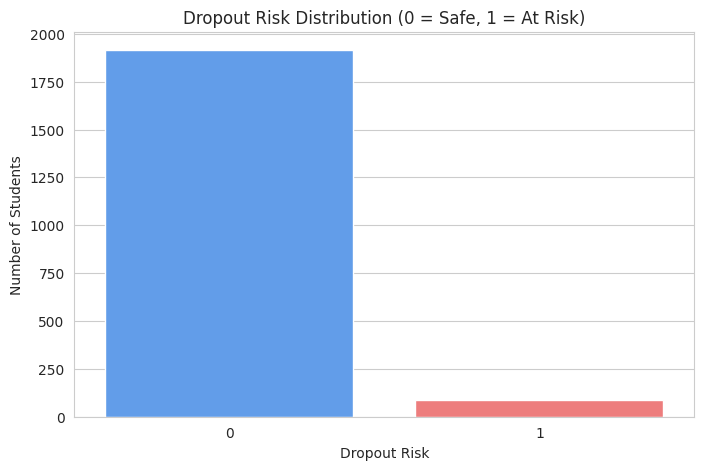

In [7]:
print("Dropout Risk class distribution:")
print(df['Dropout_Risk'].value_counts())
print()
print(f"Dropout rate: {df['Dropout_Risk'].mean()*100:.2f}%")

sns.countplot(x='Dropout_Risk', data=df, palette=['#4C9AFF', '#FF6B6B'])
plt.title('Dropout Risk Distribution (0 = Safe, 1 = At Risk)')
plt.xlabel('Dropout Risk')
plt.ylabel('Number of Students')
plt.show()


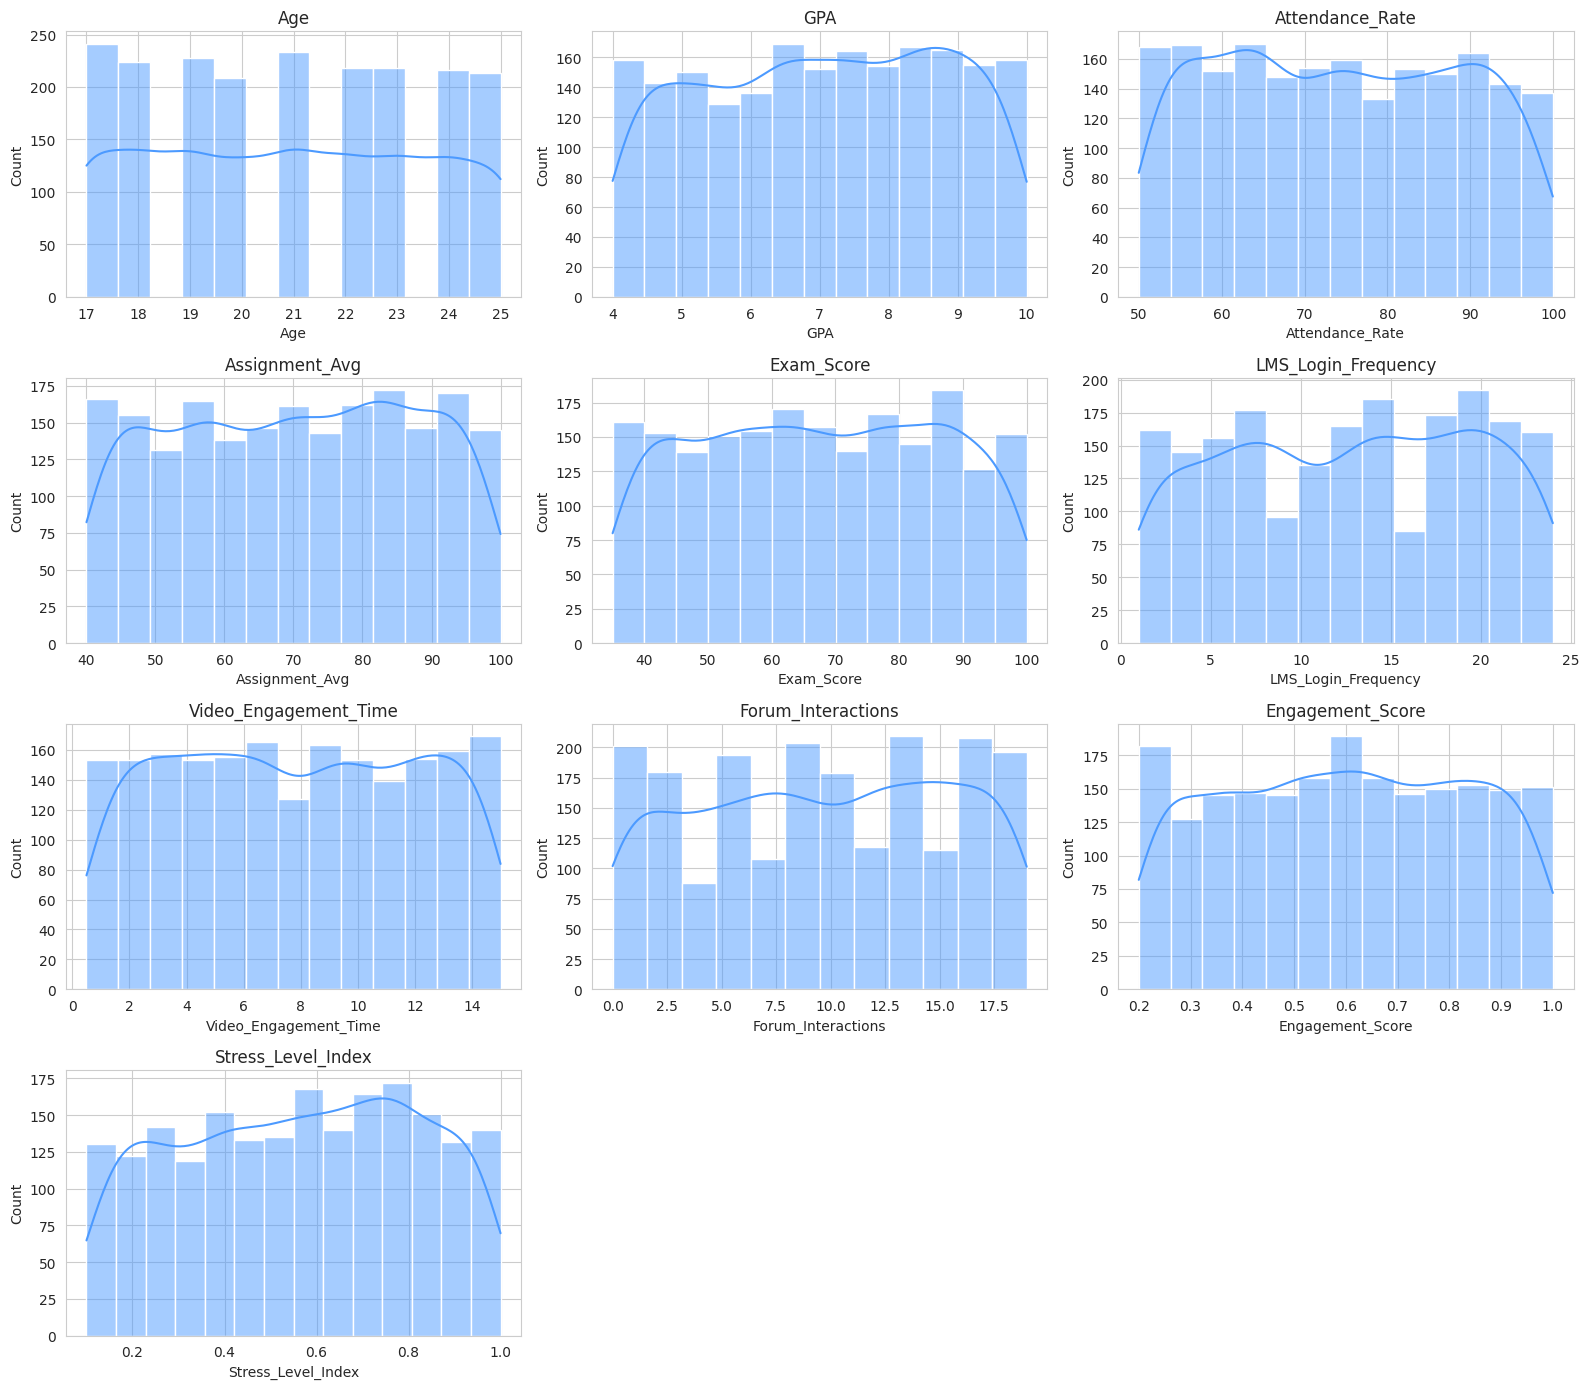

In [8]:

num_cols = ['Age','GPA','Attendance_Rate','Assignment_Avg','Exam_Score',
            'LMS_Login_Frequency','Video_Engagement_Time','Forum_Interactions',
            'Engagement_Score','Stress_Level_Index']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C9AFF')
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


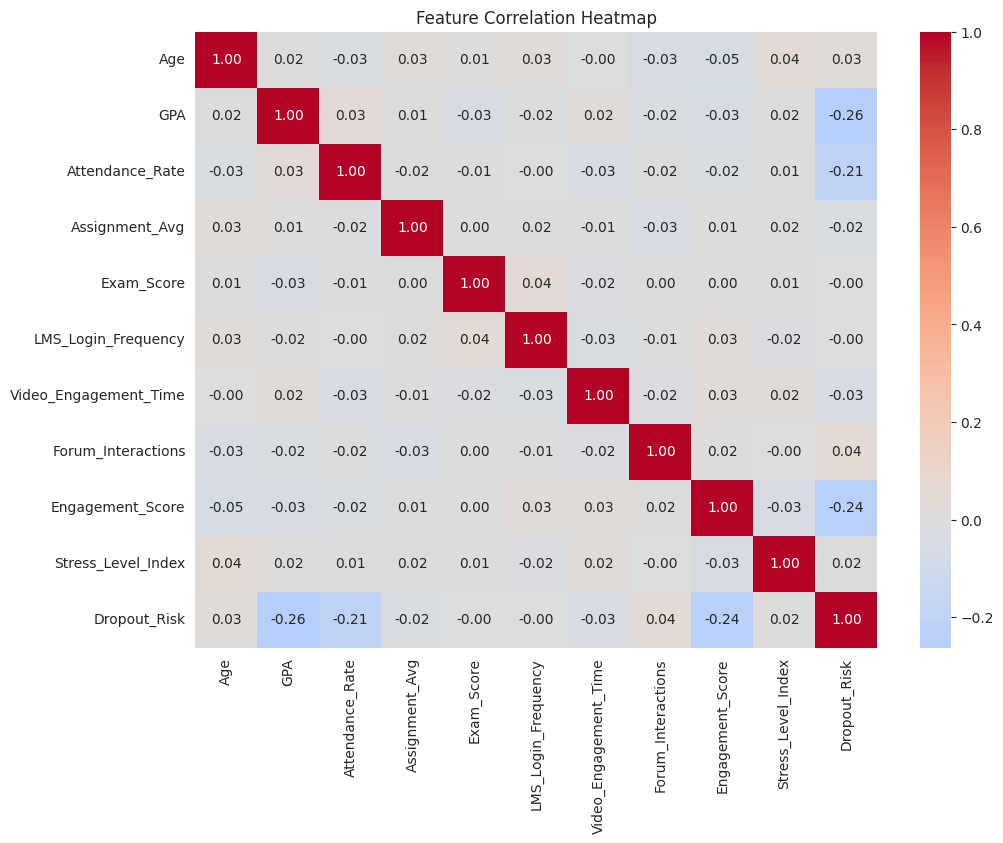

In [9]:

plt.figure(figsize=(11, 8))
corr = df[num_cols + ['Dropout_Risk']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()


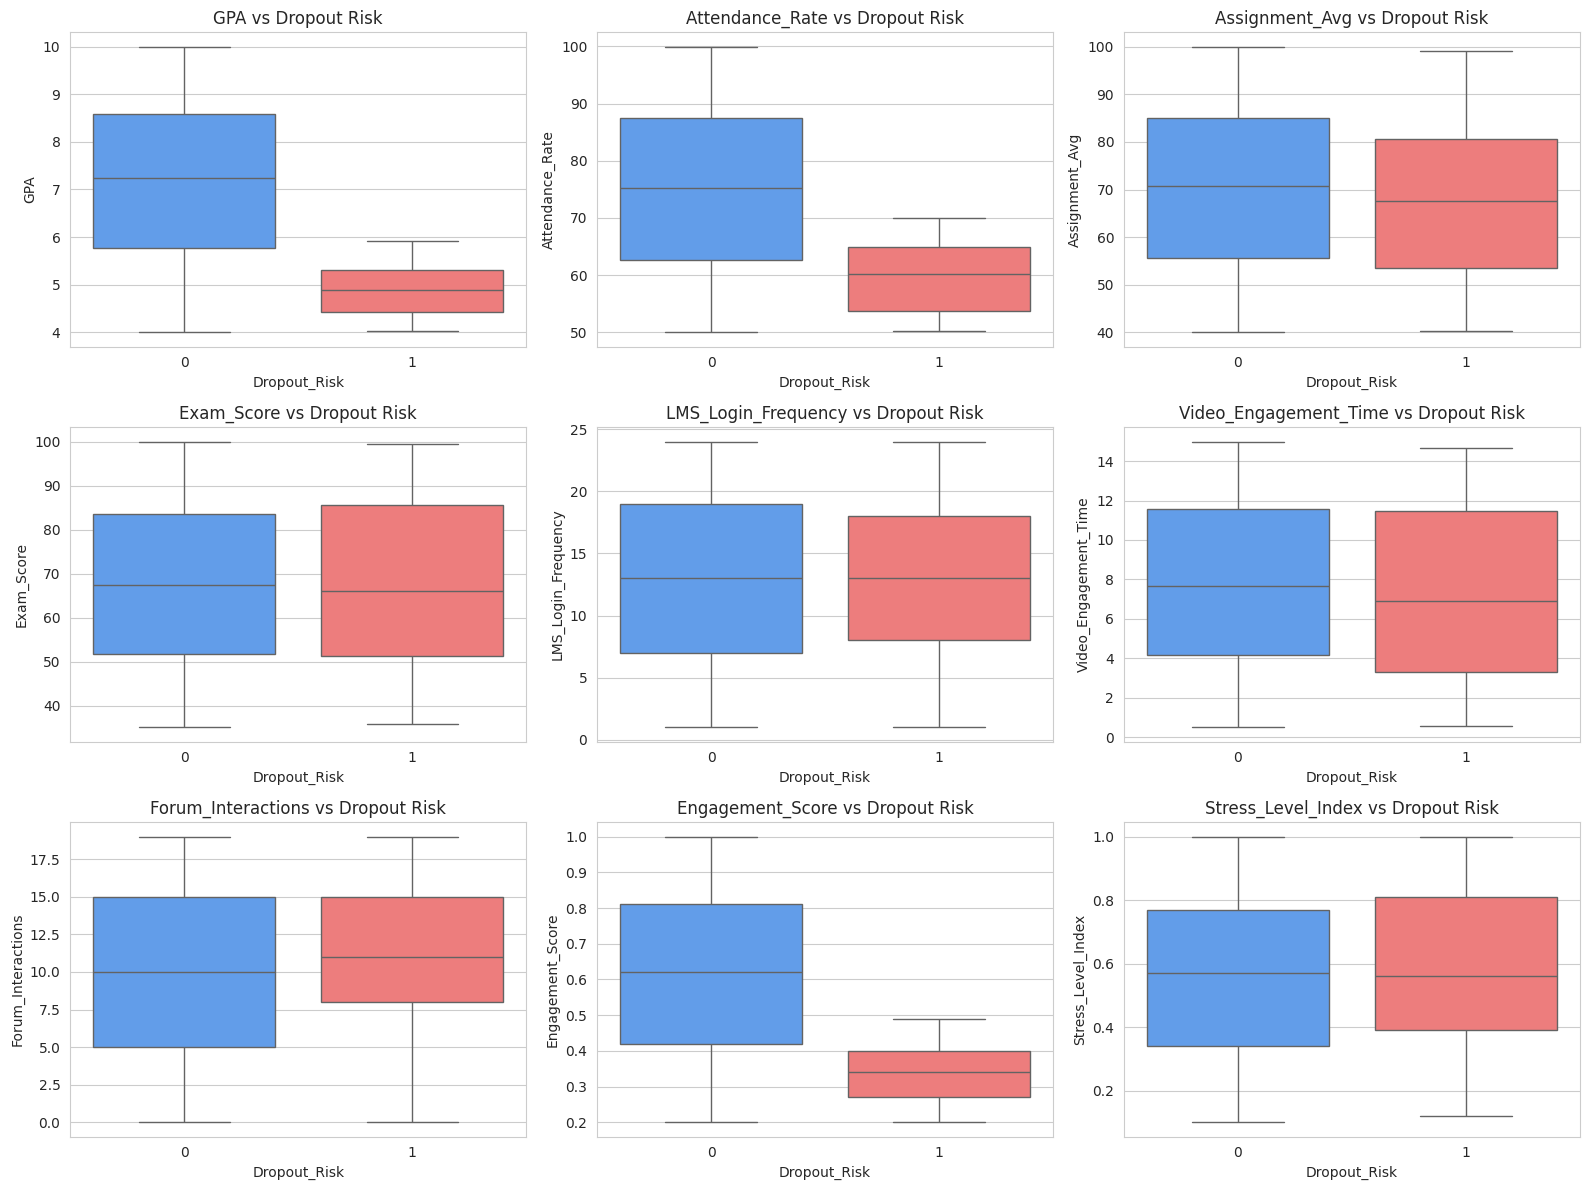

In [10]:

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
compare_cols = ['GPA','Attendance_Rate','Assignment_Avg','Exam_Score',
                'LMS_Login_Frequency','Video_Engagement_Time',
                'Forum_Interactions','Engagement_Score','Stress_Level_Index']
for i, col in enumerate(compare_cols):
    sns.boxplot(x='Dropout_Risk', y=col, data=df, ax=axes[i], palette=['#4C9AFF','#FF6B6B'])
    axes[i].set_title(f'{col} vs Dropout Risk')
plt.tight_layout()
plt.show()


In [11]:
feature_cols = [c for c in df.columns if c not in ['Student_ID', 'Dropout_Risk']]
X = df[feature_cols]
y = df['Dropout_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class distribution:\n{y_train.value_counts()}")


Train shape: (1600, 10), Test shape: (400, 10)
Train class distribution:
Dropout_Risk
0    1532
1      68
Name: count, dtype: int64


In [12]:

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())


Before SMOTE: {0: 1532, 1: 68}
After SMOTE: {0: 1532, 1: 1532}


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba
    }

results_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if k in ["accuracy","precision","recall","f1","roc_auc"]}
    for name, r in results.items()
}).T.sort_values("f1", ascending=False)

results_df.style.background_gradient(cmap='Blues')


,accuracy,precision,recall,f1,roc_auc
Decision Tree,0.997500,1.000000,0.941176,0.969697,0.970588
Random Forest,0.995000,1.000000,0.882353,0.937500,0.998003
SVM (RBF),0.965000,0.565217,0.764706,0.650000,0.980955
Logistic Regression,0.937500,0.388889,0.823529,0.528302,0.973890


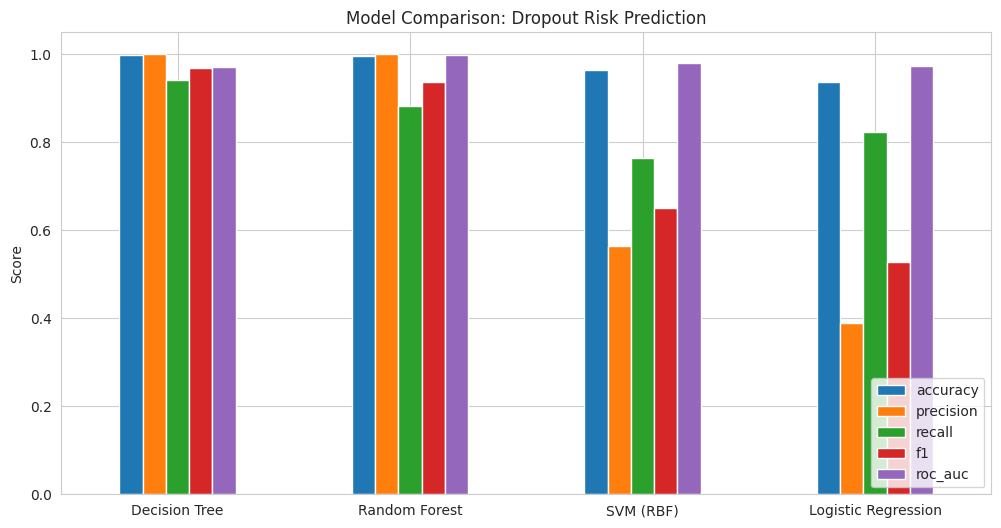

In [14]:
results_df.plot(kind='bar', figsize=(12,6))
plt.title('Model Comparison: Dropout Risk Prediction')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1.05)
plt.show()


In [15]:
best_model_name = results_df['f1'].idxmax()
best_model = results[best_model_name]["model"]
print(f"Best model based on F1-score: {best_model_name}")

y_pred_best = results[best_model_name]["y_pred"]
y_proba_best = results[best_model_name]["y_proba"]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Safe','At Risk']))


Best model based on F1-score: Decision Tree

Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00       383
     At Risk       1.00      0.94      0.97        17

    accuracy                           1.00       400
   macro avg       1.00      0.97      0.98       400
weighted avg       1.00      1.00      1.00       400



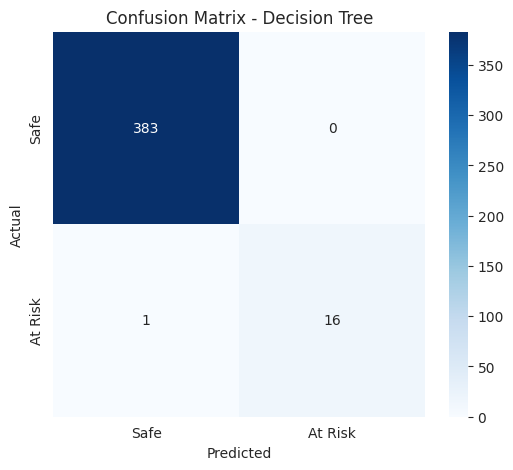

In [16]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe','At Risk'], yticklabels=['Safe','At Risk'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


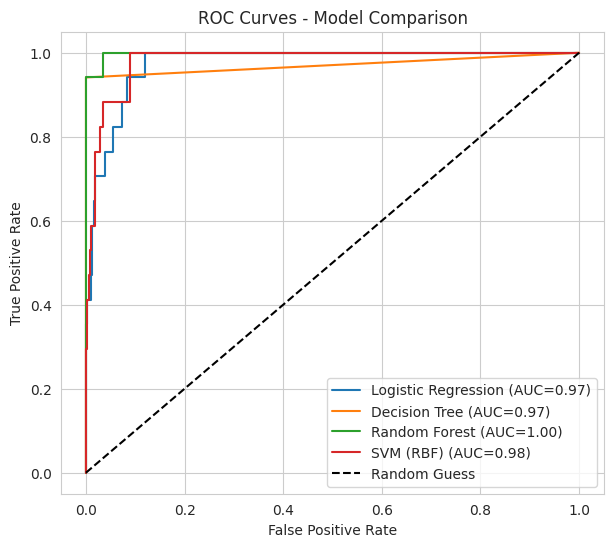

In [17]:
plt.figure(figsize=(7,6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.2f})")
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.show()


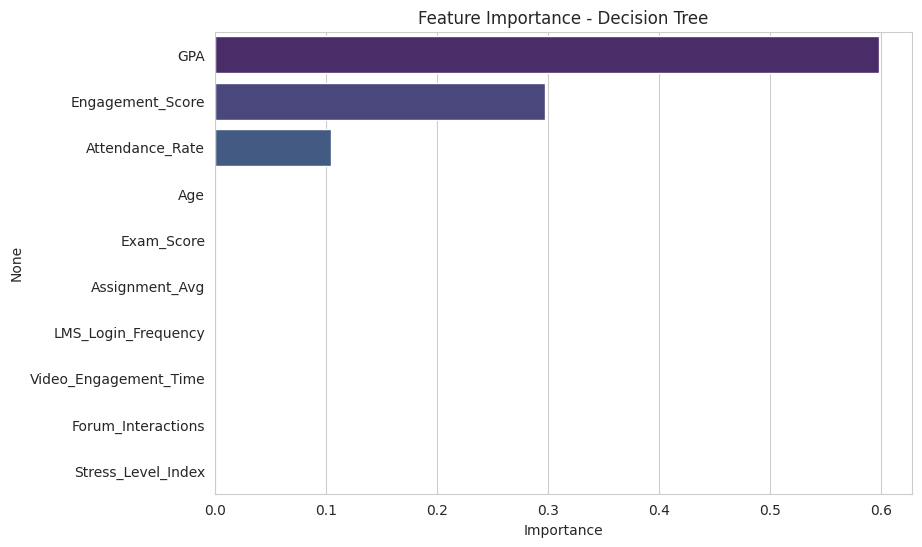

In [18]:

if best_model_name in ["Random Forest", "Decision Tree"]:
    importances = pd.Series(best_model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(9,6))
    sns.barplot(x=importances.values, y=importances.index, palette='viridis')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.show()
else:
    # Fall back to a Random Forest just to inspect importance
    rf_ref = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
    rf_ref.fit(X_train_bal, y_train_bal)
    importances = pd.Series(rf_ref.feature_importances_, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(9,6))
    sns.barplot(x=importances.values, y=importances.index, palette='viridis')
    plt.title('Feature Importance (Random Forest reference)')
    plt.xlabel('Importance')
    plt.show()


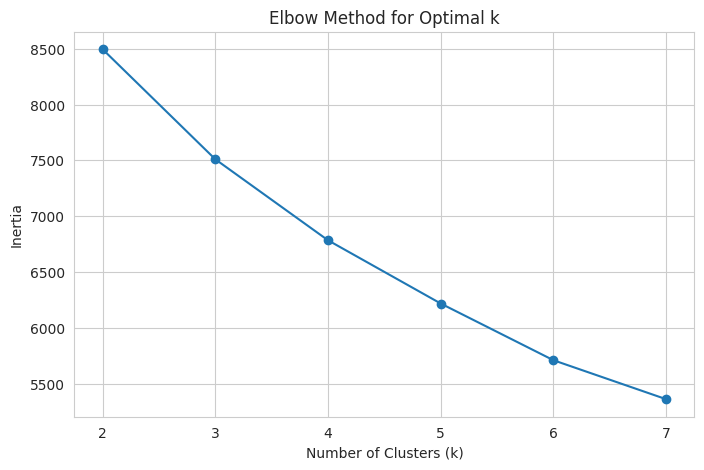

In [19]:
cluster_features = ['Attendance_Rate','Assignment_Avg','Exam_Score',
                     'Engagement_Score','Stress_Level_Index']
X_cluster = StandardScaler().fit_transform(df[cluster_features])

inertia = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


In [20]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Classroom_Segment'] = kmeans.fit_predict(X_cluster)

segment_profile = df.groupby('Classroom_Segment')[cluster_features + ['Dropout_Risk']].mean()
segment_profile['Count'] = df['Classroom_Segment'].value_counts()
segment_profile


,Attendance_Rate,Assignment_Avg,Exam_Score,Engagement_Score,Stress_Level_Index,Dropout_Risk,Count
Classroom_Segment,,,,,,,
0,73.279357,69.074229,66.121000,0.625829,0.281129,0.035714,700
1,75.418283,68.674744,85.133886,0.611476,0.699006,0.034639,664
2,74.308396,72.998160,50.525157,0.557170,0.727516,0.058176,636


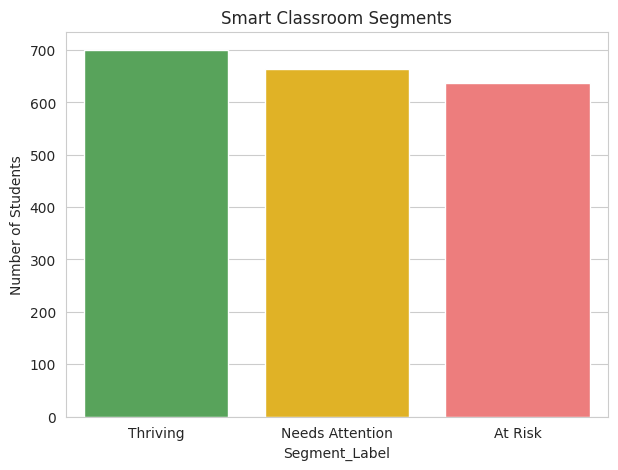

,Student_ID,Segment_Label
0,STD00001,Needs Attention
1,STD00002,Thriving
2,STD00003,At Risk
3,STD00004,Needs Attention
4,STD00005,Needs Attention
5,STD00006,Needs Attention
6,STD00007,Needs Attention
7,STD00008,Thriving
8,STD00009,Thriving
9,STD00010,Needs Attention


In [21]:

order = segment_profile.sort_values('Engagement_Score', ascending=False).index
labels_map = {order[0]: 'Thriving', order[1]: 'Needs Attention', order[2]: 'At Risk'}
df['Segment_Label'] = df['Classroom_Segment'].map(labels_map)

plt.figure(figsize=(7,5))
sns.countplot(x='Segment_Label', data=df,
              order=['Thriving','Needs Attention','At Risk'],
              palette=['#4CAF50','#FFC107','#FF6B6B'])
plt.title('Smart Classroom Segments')
plt.ylabel('Number of Students')
plt.show()

df[['Student_ID','Segment_Label']].head(10)


In [22]:
joblib.dump(best_model, 'dropout_risk_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(kmeans, 'classroom_segment_model.pkl')

print("Saved files:")
print(" - dropout_risk_model.pkl")
print(" - feature_scaler.pkl")
print(" - classroom_segment_model.pkl")


Saved files:
 - dropout_risk_model.pkl
 - feature_scaler.pkl
 - classroom_segment_model.pkl


In [23]:
def assess_student(student_dict):
    """
    student_dict: dict with keys matching feature_cols, e.g.
    {
        'Age': 21, 'GPA': 5.2, 'Attendance_Rate': 55.0, 'Assignment_Avg': 40.0,
        'Exam_Score': 38.0, 'LMS_Login_Frequency': 4, 'Video_Engagement_Time': 2.5,
        'Forum_Interactions': 1, 'Engagement_Score': 0.25, 'Stress_Level_Index': 0.9
    }
    """
    x = pd.DataFrame([student_dict])[feature_cols]
    x_scaled = scaler.transform(x)
    risk_prob = best_model.predict_proba(x_scaled)[0, 1]
    risk_pred = int(risk_prob >= 0.5)

    if risk_prob >= 0.7:
        action = " High risk — recommend immediate advisor meeting and academic support plan."
    elif risk_prob >= 0.4:
        action = " Moderate risk — recommend check-in and monitor engagement over next 2 weeks."
    else:
        action = " Low risk — student appears on track."

    return {
        "dropout_probability": round(float(risk_prob), 3),
        "predicted_at_risk": bool(risk_pred),
        "recommended_action": action
    }


sample_student = {
    'Age': 22, 'GPA': 4.8, 'Attendance_Rate': 48.0, 'Assignment_Avg': 35.0,
    'Exam_Score': 32.0, 'LMS_Login_Frequency': 3, 'Video_Engagement_Time': 1.8,
    'Forum_Interactions': 0, 'Engagement_Score': 0.20, 'Stress_Level_Index': 0.92
}

assess_student(sample_student)


{'dropout_probability': 1.0,
 'predicted_at_risk': True,
 'recommended_action': ' High risk — recommend immediate advisor meeting and academic support plan.'}